# The math that's killing your AI agent

**Chain 10 steps at 85% per-step accuracy and your end-to-end success rate is 19.7%.**

This notebook makes that sentence runnable: the arithmetic, a Monte Carlo check that
it isn't a simulation quirk, the two mitigations that rescue it, and what each one
costs in LLM calls.

Companion to the book *Why Your AI Agent Will Fail* and the article
[The Math That's Killing Your AI Agent](https://satsawat.ai) ·
Newsletter: [AI in Practice](https://satsawat.ai/#newsletter)


In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
sys.path.insert(0, str(_here.parent if (_here.parent / "failure_lab").exists() else _here))

import random
from failure_lab.model import (
    MITIGATIONS, chain_success, expected_calls,
    required_step_accuracy, simulate_chain,
)
from failure_lab.charts import (
    collapse_by_accuracy_fig, mitigation_fig, cost_fig,
)
%matplotlib inline

## 1. The arithmetic

No simulation needed yet. End-to-end success is just per-step accuracy raised to the
number of steps, and the table below is the whole problem:


In [2]:
p = 0.85
print(f"{'steps':>6} | end-to-end success at {p:.0%} per step")
print("-" * 42)
for n in (1, 2, 3, 5, 8, 10, 15, 20):
    print(f"{n:>6} | {chain_success(p, n):7.1%}")

 steps | end-to-end success at 85% per step
------------------------------------------
     1 |   85.0%
     2 |   72.2%
     3 |   61.4%
     5 |   44.4%
     8 |   27.2%
    10 |   19.7%
    15 |    8.7%
    20 |    3.9%


At 85% per step, a 3-step demo still works three times out of five (61%), which is
good enough to green-light the project. By 5 steps it's worse than a coin flip (44%);
by 10 it's a 1-in-5 long shot. Nothing broke. The math was always going to do this.

The collapse is steeper the further your per-step accuracy is from perfect:


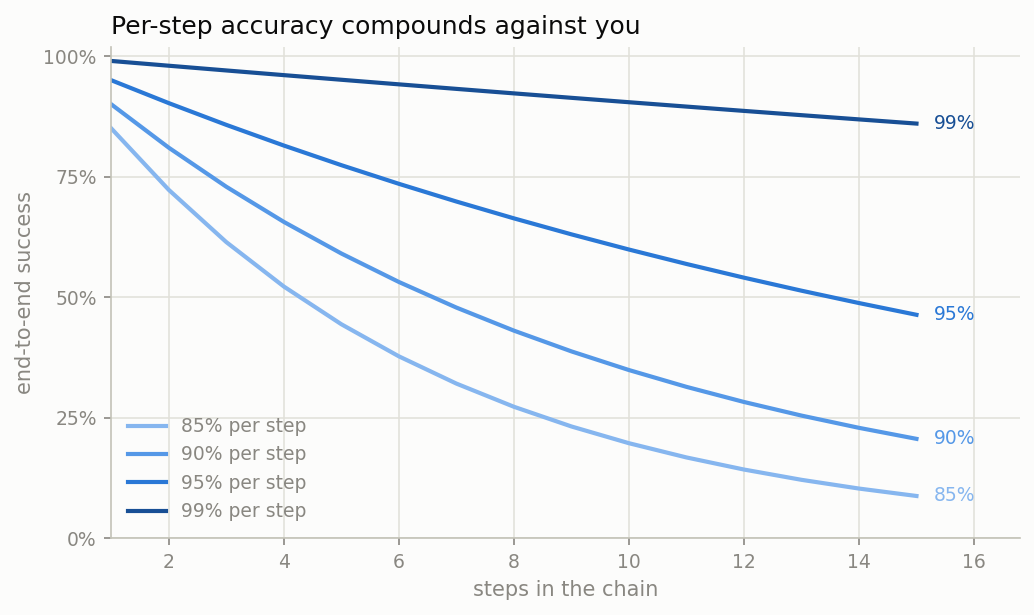

In [3]:
collapse_by_accuracy_fig();

Read the gap between the 99% line and the 85% line: at 15 steps it's the difference
between a usable product (86%) and a demo that embarrasses you in front of a customer
(9%).

## 2. This is not a simulation quirk

Analytic and Monte Carlo numbers agree. The collapse is arithmetic, not an artifact:


In [4]:
rng = random.Random(42)
print(f"{'steps':>6} | {'analytic':>9} | {'simulated':>9}   (20,000 trials)")
print("-" * 42)
for n in (1, 5, 10, 15):
    mc = simulate_chain(p, n, "none", trials=20_000, rng=rng)
    print(f"{n:>6} | {chain_success(p, n):>9.1%} | {mc.success_rate:>9.1%}")

 steps |  analytic | simulated   (20,000 trials)
------------------------------------------
     1 |     85.0% |     85.1%
     5 |     44.4% |     44.2%
    10 |     19.7% |     19.8%
    15 |      8.7% |      8.7%


## 3. The mitigations, and why *detectability* is the whole game

A failed step only gets a second chance if something notices it failed. That splits
mitigations by **how detectable the failure is**:

- **`retry`**: the failure is *code-detectable* (schema validation, tool errors,
  parse failures). Detection is free, and a detected failure gets one retry.
  Best case, but it only covers failures you can catch with code.
- **`verify`**: the failure needs an *LLM verifier* to catch (hallucinations, subtle
  reasoning errors). The verifier adds one call per step, catches a failure 90% of
  the time, and a caught failure gets one corrected attempt.
- **`none`**: failures go undetected, and the chain confidently delivers a wrong
  answer.


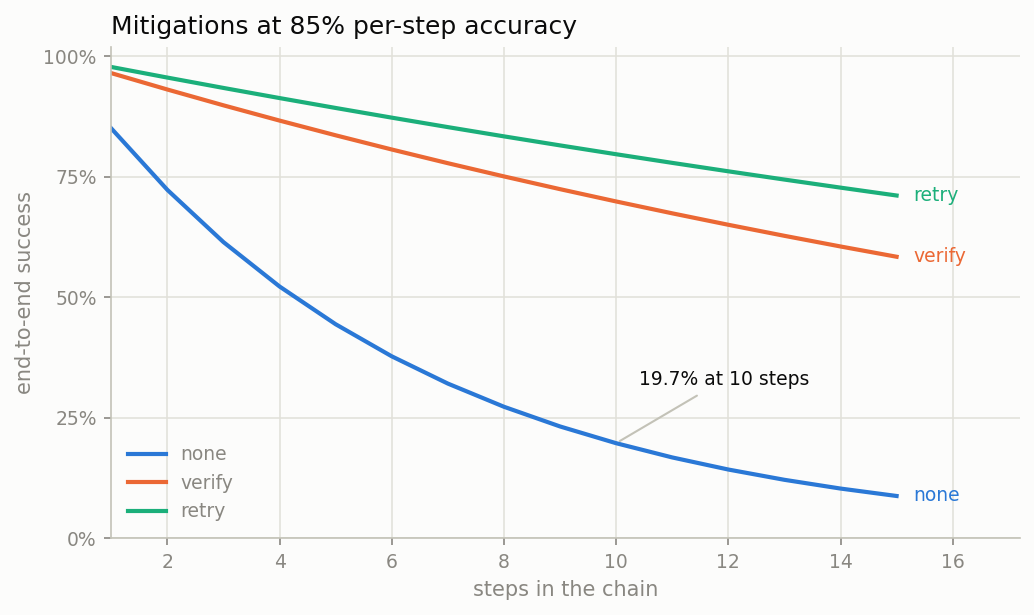

In [5]:
mitigation_fig(p);

At 10 steps: **19.7% → 69.8% (verify) → 79.6% (retry)**. Neither mitigation gets you
to production-grade on its own; they buy you room, not absolution.

## 4. What reliability costs

Mitigations aren't free. `verify` doubles your calls before it corrects anything;
`retry` only pays when a step actually fails:


mitigation |  success | expected calls
----------------------------------------
      none |    19.7% |           10.0
    verify |    69.8% |           21.4
     retry |    79.6% |           11.5


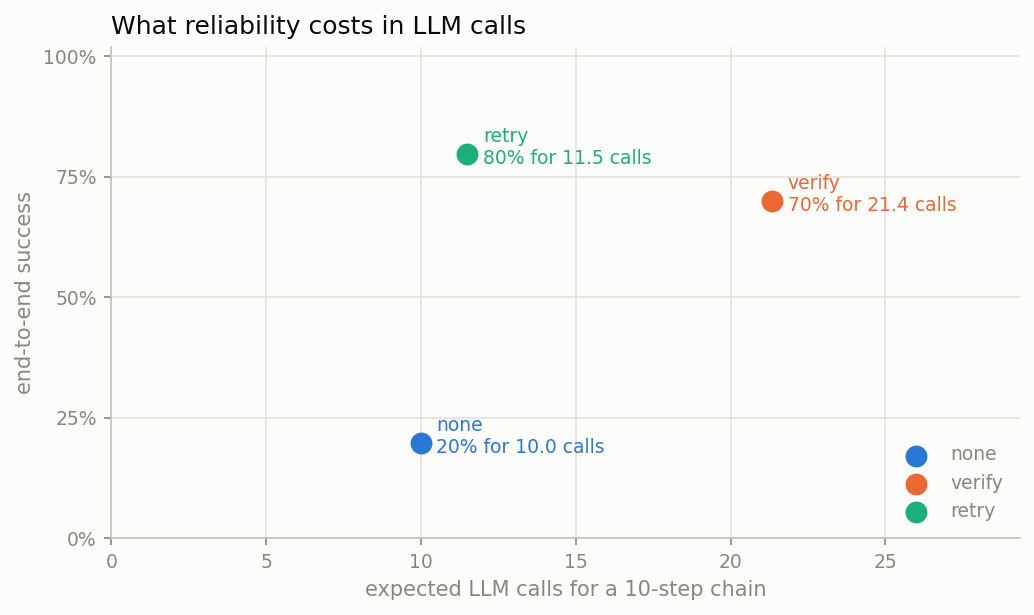

In [6]:
steps = 10
print(f"{'mitigation':>10} | {'success':>8} | {'expected calls':>14}")
print("-" * 40)
for m in MITIGATIONS:
    s = chain_success(p, steps, m)
    c = expected_calls(p, steps, m)
    print(f"{m:>10} | {s:>8.1%} | {c:>14.1f}")
cost_fig(p, steps);

The punchline: `retry` delivers **more reliability for less money** than `verify`,
*as long as the failure is code-detectable*. Real agents need both, applied per
step type: validate what code can validate, and spend verifier calls only where
hallucination lives.

## 5. The reliability budget

Flip the equation: how good does each step have to be for the end-to-end target you
promised your stakeholders?


In [7]:
print(f"{'target':>7} | {'5 steps':>8} | {'10 steps':>9} | {'20 steps':>9}")
print("-" * 44)
for t in (0.90, 0.95, 0.99):
    row = " | ".join(f"{required_step_accuracy(t, n):>8.2%}"
                     for n in (5, 10, 20))
    print(f"{t:>7.0%} | {row}")

 target |  5 steps |  10 steps |  20 steps
--------------------------------------------
    90% |   97.91% |   98.95% |   99.47%
    95% |   98.98% |   99.49% |   99.74%
    99% |   99.80% |   99.90% |   99.95%


To promise 90% over 10 steps you need **98.95% per step**, and that is before
mitigations. That number is why "the model got better" never saves a long chain
by itself.

## Takeaways

1. **Compound failure is arithmetic**, not bad luck. Plan for it before the demo.
2. **Detectability decides the mitigation**: free retries for code-detectable
   failures, paid verification for hallucinations.
3. **Reliability is an architecture property**: shorter chains, checkpoints, and
   validation gates beat waiting for a smarter model.

**Real mode:** this repo also runs an actual 8-step document agent against a
local model (`python realmode.py run`), with every step attempt logged and
classified as format error, tool error, or wrong value against conditional
ground truth. See `runs/` for the reports and failure-taxonomy charts.

---
*Satsawat Natakarnkitkul, author of* Why Your AI Agent Will Fail *·
[satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*
